In [11]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt 
from tensorflow.keras import layers ,models
from tensorflow.keras.datasets import fashion_mnist 

In [12]:
(x_train, y_train), (x_test, y_test)=fashion_mnist.load_data()

x_train=x_train/255.0
x_test=x_test/255.0

x_train=x_train.reshape(-1,28,28,1)
x_test=x_test.reshape(-1,28,28,1)


In [3]:
model= models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='softmax')
])

C:\Users\akank\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
model.fit(x_train,y_train,epochs=2,batch_size=64)

Epoch 1/2
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.8246 - loss: 0.4907
Epoch 2/2
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8799 - loss: 0.3277


In [13]:
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)

# Step 8: Predict few images
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8797 - loss: 0.3322
Test Accuracy: 0.8797000050544739
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


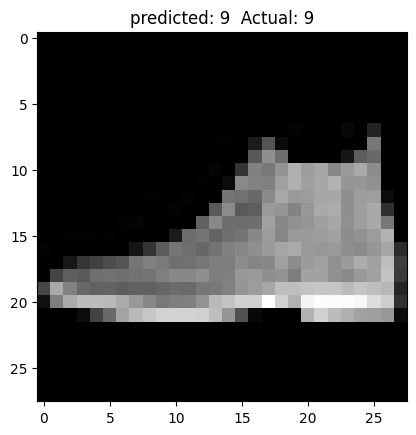

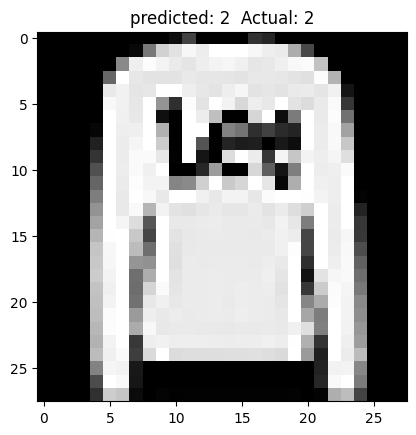

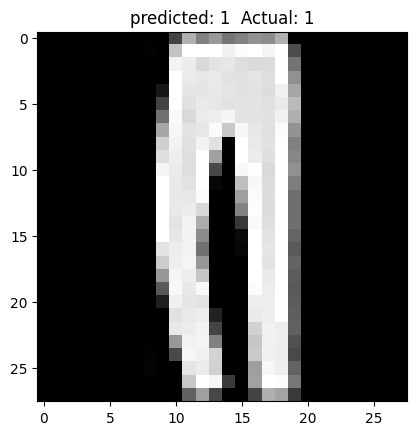

In [18]:
for i in range(3):
    
    plt.imshow(x_test[i].reshape(28,28),cmap='gray')
    plt.title(f"predicted: {str(np.argmax(predictions[i]))}  Actual: {str(y_test[i])}")
    plt.show()